### 1. midi 파일 전처리

* adn_i는 딕셔너리로, 사이클 탐색에 필요한 note = (pitch, length)의 list가 들어있습니다.
* adn_i[1][2]는 inst 1을 timeflow lag = 2로 inter_weight를 구할 때 쓰이며, adn_i[2][4]는 inst 2를 timeflow lag = 4로 inter_weight를 구할 때 쓰입니다. (그러나 search_timeflow_homology가 inter_lag를 인자로 받아 adn_i[1][inter_lag], adn_i[2][inter_lag] 간에 inter_weight를 구하므로 길이가 다른 해당 두 리스트 간에 inter_weight를 구할 일은 없습니다.)
* adn_i[1][-1]는 inst 1 전체의 화음 레이블을 시간순으로 기록한 것으로, 연주되지 않는 마지막 4마디(133~6마디)까지 포함해 길이가 1088(8 * 136)입니다.

In [1]:
from util import *
from process import *
from professor import *

file_name = "Ryuichi_Sakamoto_-_hibari.mid"
adjusted_notes, tempo = adjust_to_eighth_note(file_name)

adn_1 = adjusted_notes[:2006]
adn_2 = adjusted_notes[2006:]

adn_1_real = adn_1[:-59]
adn_2_real = adn_2[59:]

adn_1_chord = label_active_chord_by_onset(adn_1_real) # 33*59
adn_2_chord = label_active_chord_by_onset(adn_2_real) # 32*59

adn_i = get_ready_with_lags(adn_1_chord, adn_2_chord)

1th instrument ending : index 2006
2th instrument ending : index 3953


~/.venv\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


* 곡에서 반복되는 단위를 추출하고(module_notes), 각 시점에서 활성화된 음들을 모아(active_module) 화음 단위로 정제합니다.
* 화음에 대해 3가지 방식으로 딕셔너리를 만들 수 있으며, 나머지 2가지 방식은 analysis 파일에서 확인할 수 있습니다.

In [2]:
module_notes = adn_1_real[:59]
# module_chord = adn_1_chord[:32]
active_module = group_notes_with_duration_(module_notes)

notes_label, notes_counts = notes_label_n_counts(module_notes)
chord_label = chord_label_dict(active_module)

# notes = (pitch, duration)
notes_dict = chord_label_to_note_labels(chord_label, notes_label)
notes_dict['name'] = 'notes'

* 총 23개의 note가 사용되었습니다.

In [3]:
notes_label

{(52, 2): 1,
 (53, 2): 2,
 (55, 2): 3,
 (57, 2): 4,
 (57, 6): 5,
 (59, 2): 6,
 (60, 2): 7,
 (60, 6): 8,
 (62, 2): 9,
 (64, 2): 10,
 (64, 6): 11,
 (65, 2): 12,
 (65, 5): 13,
 (65, 6): 14,
 (67, 1): 15,
 (69, 1): 16,
 (69, 5): 17,
 (71, 1): 18,
 (72, 1): 19,
 (74, 1): 20,
 (76, 1): 21,
 (79, 1): 22,
 (81, 1): 23}

### 2. 중첩행렬 건설

* hibari_notes_df는 모델 학습 시 정답지로 쓰일 데이터프레임으로, 각 컬럼은 사용된 note의 label을 나타냅니다. 이때 binary(있거나 없거나 O 얼마나 많이 있나 X)이기 때문에 hibari_notes_df에서 1로 표시된 note가 해당 시점에서 inst 1, 2 모두에서 활성화됐을 수 있습니다.

In [4]:
simul_whole_c = simul_chord_lists(adn_i[1][-1], adn_i[2][-1])
simul_notes = simul_union_by_dict(simul_whole_c, notes_dict)
nodes_list = list(range(1, 23+1))
hibari_notes_df = get_correct_df(nodes_list, simul_notes)

hibari_notes_df[:5]

,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
0,1,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0


* 폴더명이 pickle 폴더에서 timeflow cycle을 불러옵니다. 
  * (파일명 해석) note 단위로 refine하였고 inter_lag는 1, timeflow_weight = intra_weights + rate_t * inter_weight에서 rate_t를 0에서 1.5까지 0.0001(1e-4) 간격으로 증가시키며 나타나는 사이클을 추적하였습니다.
* rate_t는 곡에서 반복되는 모듈 중심으로 청취하지 않고, 사운드를 있는 그대로 듣는 비율을 의미할 수 있습니다.
  * 단선율에 대한 선행연구에선 인접한(inter_lag = 1) 두 음 사이의 가중치를 1로 주었는데, rate_t = 1일 때가 선행연구의 세팅과 상응합니다.
  * 그러나 실제로 음악을 청취할 때면 곡의 중반 즈음에 혼란해지기 전까진 아무래도 모듈 중심으로 선율을 인식하게 됩니다, 주관적으로.

#### 2-1. 기존에 탐색해 둔 사이클(h1) 호출

In [5]:
cycle_persistence_1 = homol_rBD_from_pkl('h1_rBD_t_notes1_1e-4_0.0~1.5.pkl', dir="./pickle")

* key : 사이클의 구성성분(실제 연결 순서를 가장 작은 레이블을 가진 vertex(note)부터 나열)
* value : list[tuple] where tuple = (사이클이 나타난 rate_t, Birth, Death) (2, 3rd value is in the sense of Vietoris-Rips Complex's filtration value)

In [6]:
print(cycle_persistence_1.keys())
print(cycle_persistence_1[(0, 15, 8, 18)][:3])

dict_keys([(2, 20, 17, 6, 5, 18), (0, 1, 2, 18, 5), (0, 15, 22, 1), (0, 5, 18, 19, 22, 1), (0, 15, 8, 18), (0, 6, 9, 1), (0, 6, 17, 1), (2, 9, 11, 5, 3), (5, 11, 9, 18, 19), (5, 11, 9, 15), (5, 16, 14, 18), (0, 1, 9, 18, 5), (1, 9, 18, 5, 15, 22), (1, 9, 18, 19, 22), (5, 18, 9, 10), (0, 1, 9, 11, 5), (3, 9, 10, 5), (0, 19, 22, 1), (0, 1, 22, 15), (5, 13, 9, 11), (5, 12, 9, 10), (0, 13, 9, 14, 16), (0, 13, 9, 14, 18, 5), (3, 9, 12, 5), (0, 5, 18, 14, 9, 13), (2, 9, 10, 5, 3), (3, 9, 13, 5), (2, 9, 13, 5, 3), (0, 13, 8, 15), (5, 11, 9, 10), (3, 9, 14, 16, 5), (2, 9, 12, 5, 3), (3, 9, 16, 5), (5, 11, 9, 13), (2, 9, 16, 5, 3), (0, 6, 9, 10, 5), (5, 10, 9, 11), (5, 6, 9, 12), (5, 10, 9, 13), (5, 6, 9, 15), (5, 6, 9, 16), (5, 11, 9, 18), (0, 5, 10, 9, 1), (2, 3, 5, 6, 9), (8, 13, 9, 15), (5, 6, 9, 18, 8, 15), (5, 10, 9, 12), (5, 10, 9, 18)])
[(0.0001, 0.007691952679107118, 0.007692142015402745), (0.0002, 0.007691597698673968, 0.007691976345634343), (0.0003, 0.007691242751003707, 0.0076918106

* label_cycle의 인자 log를 True로 놓고 실행하면 각 note들이 얼마나 많은 사이클에 포함되었고, 어느 사이클에도 포함되지 않은 note는 무엇이 있는지, 각 사이클들의 길이는 얼마나 되는지를 알 수 있습니다. log = False로 실행해도 2, 3번째 리턴값에서 볼 수 있습니다.
* cycles_weak는 모델 학습 시 쓸 입력값을 얻는데 쓰입니다. 컬럼은 사이클의 레이블이고, 로우는 각 시점입니다.

In [7]:
from util import label_cycle, get_scattered_cycles_df

cycle_labeled, length_counts_in_c, note_counts_in_c = label_cycle(cycle_persistence_1, transform_dict = notes_dict, log = False)
cycles_weak = get_scattered_cycles_df(df = hibari_notes_df, cycle_labeled = cycle_labeled, binary = True)

* 11번 시점, 즉 2번째 마디 3번째 박자엔 5, 6번 사이클에 포함된 note들이 연주되고 있음이 확인됩니다.
* binary = False로 두면 얻어지는 cycles_strong은 실제로 해당 시점에서 연주(활성화)되고 있는 note들을 보여줍니다.

In [8]:
cycles_weak.loc[10, :]

0     0
1     0
2     0
3     0
4     0
5     1
6     1
7     0
8     0
9     0
10    1
11    1
12    1
13    0
14    0
15    1
16    0
17    1
18    0
19    0
20    0
21    0
22    1
23    0
24    0
25    0
26    0
27    1
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    1
37    0
38    0
39    1
40    0
41    1
42    0
43    0
44    1
45    0
46    0
47    1
Name: 10, dtype: int64

* 아래와 같이 실행하면 cycles_weak에서 각 사이클(컬럼)별로 1이었던 로우의 비율을 threshold의 비율로 줄여주는 scale을 탐색합니다. 이때 scale의 의미는 선행연구를 참고하세요.
  * 사실 2, 3번째 리턴값은 모델링에 쓰이진 않고 확인용입니다. evaluate_threshold의 리턴값인 for_scores는 밑에서 xml파일로 출력하여 실제 악보롤 들어보기 위함이고, cycles_scaled_stat도 각 사이클이 몇 scale을 가져야 하는지, 그리고 output_dir에 png파일로 저장된 정보를 요약해서 보여줍니다.
  * 1번째 리턴값이 모델 학습 시 입력값으로 쓰일 텐데, 이는 (cycle label, list of consecutive indices after scaled)로 이뤄져있어 스케일에 대한 정보는 포함되어 있지 않습니다, 중첩행렬 건설에는 이것만이 필요하며 밑에 get_cycles_scaled 함수를 사용하면 이것만 얻을 수 있습니다.

In [15]:
from util import evaluate_threshold, get_now

threshold = 0.35
lower_bound = None # 으로 입력 시 = np.max(0.0, threshold - 0.1)
timestamp = get_now()
output_dir = f'scale_evaluation/{timestamp}_goal{threshold}'

for_overlap, for_scores, cycles_scaled_stat = evaluate_threshold(cycles_weak, cycle_labeled, threshold, lower_bound, output_dir)

Working on 1th / 48 cycle : [1, 2, 3, 19, 6]
Working on 2th / 48 cycle : [1, 2, 10, 12, 6]
Working on 3th / 48 cycle : [1, 2, 10, 19, 6]
Working on 4th / 48 cycle : [1, 2, 23, 16]
Working on 5th / 48 cycle : [1, 6, 11, 10, 2]
Working on 6th / 48 cycle : [1, 6, 19, 15, 10, 14]
Working on 7th / 48 cycle : [1, 6, 19, 20, 23, 2]
Working on 8th / 48 cycle : [1, 7, 10, 2]
Working on 9th / 48 cycle : [1, 7, 10, 11, 6]
Working on 10th / 48 cycle : [1, 7, 18, 2]
Working on 11th / 48 cycle : [1, 14, 9, 16]
Working on 12th / 48 cycle : [1, 14, 10, 15, 17]
Working on 13th / 48 cycle : [1, 14, 10, 15, 19, 6]
Working on 14th / 48 cycle : [1, 16, 9, 19]
Working on 15th / 48 cycle : [1, 16, 23, 2]
Working on 16th / 48 cycle : [1, 20, 23, 2]
Working on 17th / 48 cycle : [2, 10, 19, 6, 16, 23]
Working on 18th / 48 cycle : [2, 10, 19, 20, 23]
Working on 19th / 48 cycle : [3, 4, 6, 7, 10]
Working on 20th / 48 cycle : [3, 10, 11, 6, 4]
Working on 21th / 48 cycle : [3, 10, 12, 6, 4]
Working on 22th / 48 cyc

In [17]:
cycles_scaled_stat[:5]

,cycle,scale,mean(on),std(on),mean(off),std(off),scale reduction(%)
0,"[1, 2, 3, 19, 6]",14,15.10,0.54,31.16,73.16,66.18
1,"[1, 2, 10, 12, 6]",170,170.00,0.00,359.00,0.00,63.04
2,"[1, 2, 10, 19, 6]",186,194.00,8.00,343.00,0.00,58.94
3,"[1, 2, 23, 16]",6,7.33,1.25,34.57,67.71,68.57
4,"[1, 6, 11, 10, 2]",378,378.00,0.00,355.00,173.00,63.65


* construct_overlap_df를 통해 모델 학습의 입력값을 얻고, 
* analyze_scale_reduction을 통해 cycles_weak에서 1의 비율(ON ratio)과 그것이 얼마로 줄어들었는지, 그리고 그것이 얼마만큼의 감소에 해당하는지 출력합니다.

In [18]:
overlapped_cycles = construct_overlap_df(for_overlap)
actual_on = analyze_scale_reduction(cycles_weak, overlapped_cycles, threshold)

# overlapped_cycles.head(5)

for hibari scores, ON ratio was originally 86.37%
which decreased to 28.7% after applying cyclewise scale

it amounts to 66.77% reduction
while it was 65.0% that i tried


#### 2-2. 고민 필요

* 주석처리해놓은 이 부분은 추후에 더 깊게 생각해볼 부분으로, 컬럼 단위로 1의 총합이 같은 컬럼들을 조회하고

In [ ]:
# overlapped_cycles.sum().value_counts() 
column_sums = overlapped_cycles.sum()

from collections import defaultdict

# 합계 값을 key로 하고, 컬럼 이름을 value로 하는 딕셔너리 생성
sum_to_columns = defaultdict(list)
for col, sum_val in column_sums.items():
    sum_to_columns[sum_val].append(col)

# 합계 값이 같은 컬럼들만 출력 (리스트 길이가 1보다 큰 경우)
multi_val = []
for sum_val, columns in sum_to_columns.items():
    if len(columns) > 1:
        print(f"합계 {sum_val}: {columns}")
        multi_val.append(sum_val)

* 각 컬럼에 해당하는 사이클의 node들이 얼마나 비슷한지 보려고 했습니다.
  * 겹치는 node들 말고 그렇지 않은 node들에 대해서 (e.g. 합계가 128인 3개의 사이클 중 19번 note) 학습 시 부적절한 압축, 혹은 묽어짐이 발생할 거 같아서
  * 만약 threshold를 통해 목표한 scale reduction과 완전히 일치하지 않는 경우 해당 사이클을 대상으로 미세조정이 필요할 것 같습니다.
  * 예를 들면, scale된 이후에 꼭 연속적이지 않더라도 해당 컬럼들 간 차이를 주기 위해 겹치지 않는 node들이 연주되는 시점에 1을 준다던가, 하는 식으로. 

* 또한 label_cycle 함수를 log = True로 실행했을 때 확인할 수 있는 "어떤 사이클에도 포함되지 않은 음들"의 경우에는,
* 확인해보니 해당 음이 포함된 화음의 다른 음(*)들은 사이클이 생기는(아직 이유를 찾지 못한) 현상이 발견됐는데,
* 중첩행렬에서 어떤 사이클도 포함되지 않은 시점에서라야 Algorithm1에서는 node_union 로직을 따라 랜덤하게 추출될 가능성이 있습니다.

In [14]:
# for sum_val in multi_val :
#     print(f"cycles whose on-value are the same as {sum_val}:")
#     for cycle_idx in sum_to_columns[sum_val]:
#         print(cycle_labeled[cycle_idx])
#     print("\n")

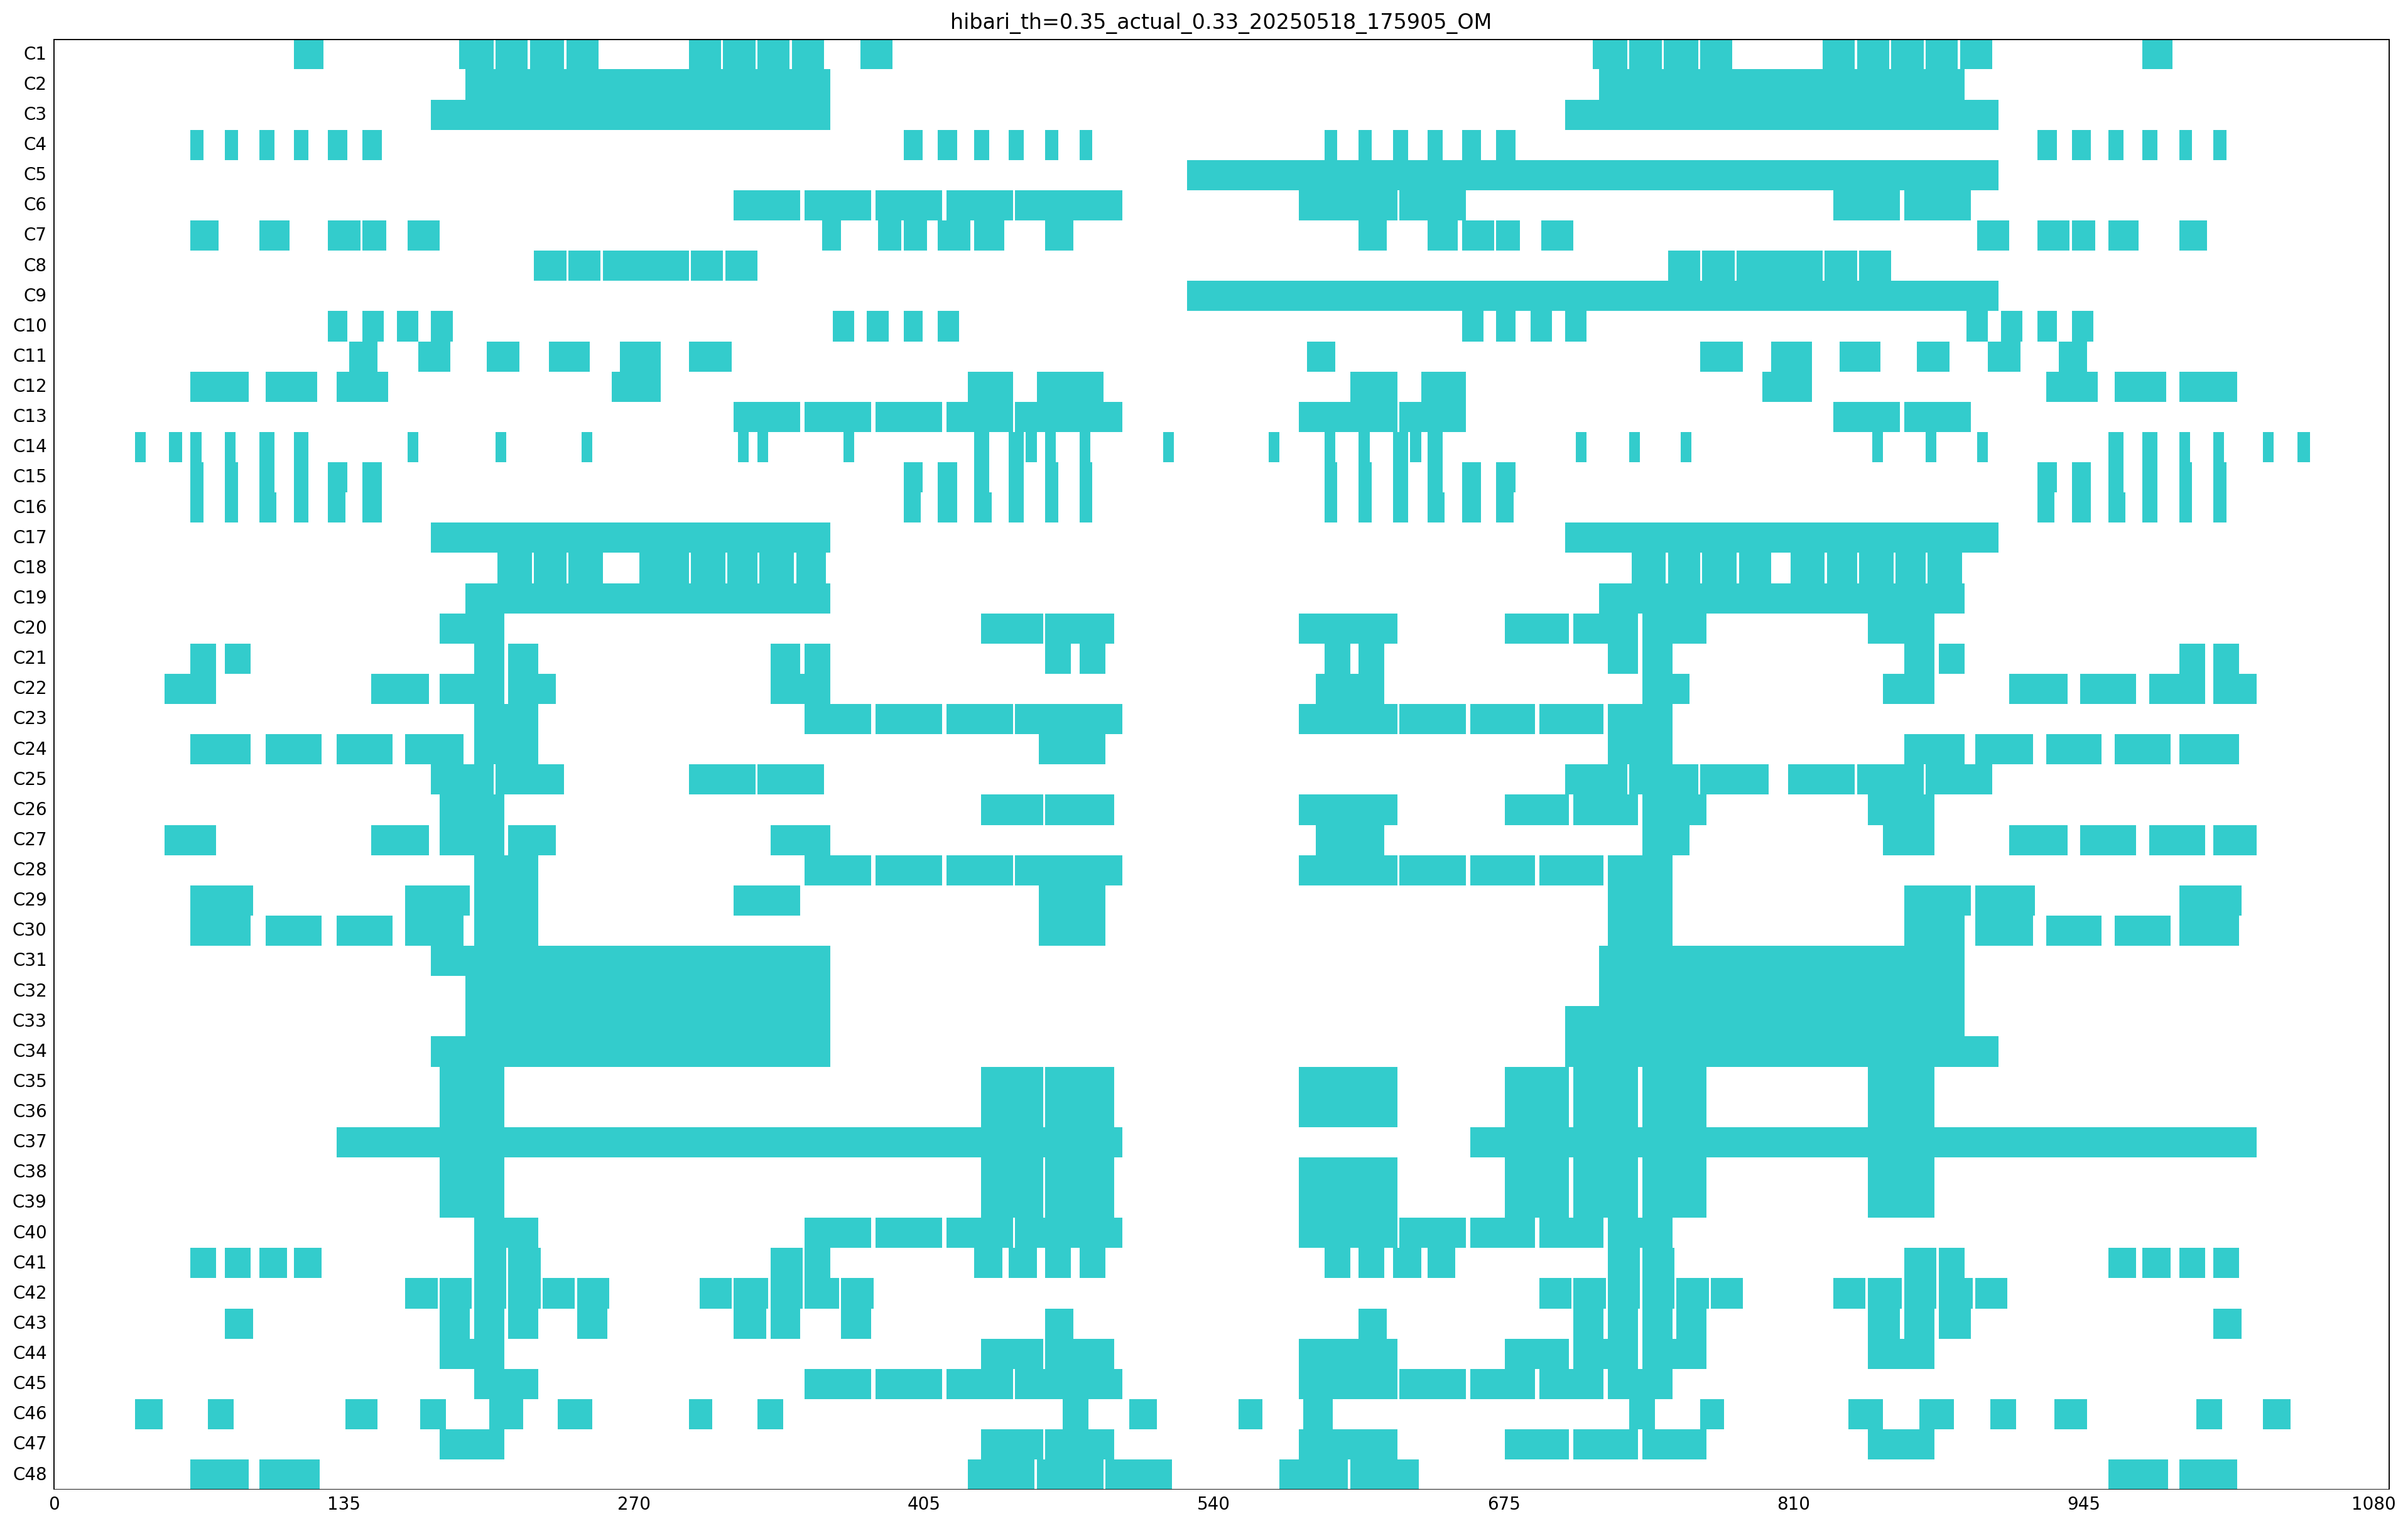

In [19]:
# 아래는 중첩행렬 시각화 함수입니다. 
from professor import plot_OM

timestamp = get_now()
songname = f'hibari_th={threshold}_actual_{round(actual_on, 2)}_{timestamp}'
plot_OM(overlapped_cycles, songname)

* 가운데에선 연주되고 있는 사이클이 거의 없는 게... 대부분의 사이클이 다 intra_weights-based란 뜻인가? rate_t > 0일 때 나타나기 시작한 사이클들마저?
* 하지만 중반(540즈음)에선 ABA'C에서 inst 1의 A랑 inst 2의 A'이랑 겹쳐져서 혼란함이 줄어든 상태(local minimal)고 그 앞뒤로가 혼란함이 늘어나는 양상이니까... (해석 필요)

* 추후에 따로 timestamp랑 threshold 따서 폴더 만들도록 수정
* flexible_pitches는 note = (pitch, duration)에서 pitch값이 같은데 다른 duration으로 나타나는 pitch들을 반환합니다.
* xml파일로 출력하며 output_dir 인자를 통해 파일을 저장할 폴더를 지정할 수 있습니다(default = "./test_xml", test_xml 폴더를 만들어야 합니다.)

In [76]:
# from process import verify_cycles_scaled_by_scores, get_flexible_pitches

# hibari_lists = [adn_1_real, adn_2_real]
# flexible_pitches = get_flexible_pitches(notes_counts, notes_label, log = True)
# output_dir = f'./test_xml/{get_now()}'
# type = 't' #if timeflow cycles and 'c' if complex cycles
# cycles_scaled = verify_cycles_scaled_by_scores(hibari_lists, cycle_labeled, for_scores, None, notes_label, flexible_pitches, 
#                                                output_dir = output_dir, type = type)

* 중첩행렬만 뽑고 싶으면 evaluate_threshold 대신 해당 함수 내부에 포함되어 있는 get_cycles_scaled만 실행하면 됩니다.

In [9]:
threshold_ = 0.35
for_overlap_ = get_cycles_scaled(cycles_weak, cycle_labeled, threshold_, None)
overlapped_cycles_ = construct_overlap_df(for_overlap_)

### 3. 알고리즘 1

In [10]:
import numpy as np
import random

# overlap_matrix = overlapped_cycles.to_numpy() 
overlap_matrix = overlapped_cycles_.to_numpy()
# (행, 열) = (시간, 사이클)이 되게 dataframe을 구성했으므로 교수님과 다르게 transpose해주지 않는다.

########################
# MAKE A NODE POOL & INTERSECTION
# 원곡의 노드들로 구성된 집합인 node pool을 정의하고 생성되는 곡은 이 node pool의 
# node를 이용하여 생성됩니다. 싸이클이 중첩됨은 두 싸이클이 서로 공유하는 node 가 
# 있다는 것을 의미하기 때문에 두 싸이클 집합의 교집합인 intersection 을 정의해 줍니다. 
########################
# 확률적 생성을 위해서 random 라이브러리를 불러 들입니다. 

from collections import Counter

# nodelist = list(counter.keys()) 
nodelist = list(notes_label.keys()) # 이렇게 해야 music 클래스 안의 node2idx를 쓸 수 있다.  

num_modules = 65 
notes_counts_whole = {key: value * num_modules for key, value in notes_counts.items()}
counter = Counter(notes_counts_whole) # Counter 객체로 다시 변환
countersorted = dict(sorted(counter.items(), key = lambda x: x[1], reverse = True))
node_freq = list(countersorted.values())
node_i = [nodelist.index(list(countersorted.keys())[i]) for i in range(len(nodelist))]

In [21]:
# # 바뀐 nodelist 정당성
# for idx in range(len(node_i)) :
#     for note, label in notes_label.items() :
#         if idx == label :
#             print(note)

In [11]:
nn = len(node_i)
nsum = np.sum(node_freq)

# # NODE PROBABILITY ==================================
# # 노드들의 빈도수 (중요도)를 반영하여 사용할 노드들의 확률을 계산하여 선택합니다. 
# node_prob = np.zeros(nn)
# for i in range(nn):
#     ni = node_i[i]
#     node_prob[ni] = node_freq[i]/nsum*100
#     # print(f"{nodelist[ni]} appears {node_freq[i]} times") # countersorted와 비교하면 일치한다.

# 전체곡(L)에서 무작위로 index = (0, len(L)) 를 결정합니다.  ==================================
random_index = []
while len(random_index) <nsum:
    rand_index = random.randint(0,nsum-1)
    if rand_index not in set(random_index):
        random_index.append(rand_index)

c = list(cycle_labeled.values())

# 노드 풀을 정의합니다.  ==================================
node_pool = np.zeros(nsum)
index = -1
for i in range(nn):
    k = node_freq[i]
    for j in range(k):
        index = index + 1
        node_pool[random_index[index]] = node_i[i]
node_pool = [round(x) for x in node_pool]
all_cycle_set = list(set(c[i]) for i in range(len(c))) 

all_cycle_number = []
for ci in c:
    all_cycle_number.extend(ci)

* 의문
  * node_prob은 실제론 안 쓰이고 확인용인 건가?
  * all_cycle_set에서 Cycle 연결순서에 대한 고려가 깨지는데 괜찮을라나...

* ALGO 1 수정사항
  * node_intersect 수정 : → 가장 빈도가 높은 node들만 반환 → 추가한 로직(특정 시점에서 추출된 node간 중복 금지) 하에서 오류가 생겨 그냥 빈도를 반영한 multiset을 반환하게 함

In [ ]:
# from process import get_hibari_notes

# hibari_notes = get_hibari_notes(adn_i[1][-1], adn_i[2][-1], notes_dict)

# inst1_leng = []
# inst2_leng = []
# for i in range(len(hibari_notes)) :
#     if not (hibari_notes[i][0] == None) :
#         inst1_leng.append(len(hibari_notes[i][0]))
#     else :
#         inst1_leng.append(0)

#     if not (hibari_notes[i][1] == None) :
#         inst2_leng.append(len(hibari_notes[i][1]))
#     else :
#         inst2_leng.append(0)

* 이 부분은 132마디에 해당할 inst 1을 ALGO 1으로 생성하는 데 쓰일 화음 높이 시퀀스를 구합니다.
* 각 시점에서 연주(활성화)되고 있을 음의 갯수(화음 높이)를 구하며 algorithm1 함수 내에서 
* 각 시점마다 음을 1개씩만 추출하던 기존 로직에서 해당 화음 높이만큼 반복문을 돌리는 것으로 수정했습니다.
* 아직 오류가 많습니다(음악을 추출한 후 확인해보면 inst_len이 음수로 떨어진 부분이나 0보다 큰 부분이 있다거나)
##### [예상원인 1] 
  * for num_nodes_in_a_chord in range(inst_len[j]) :
    * 이 로직에서 처음에 입력된 inst_len[j]만큼 반복문이 돌아가는지 아니면 중간에 동적으로 빼주는 게 반영되는지 확인해봐야 한다.

In [12]:
modules = [4, 4, 4, 3, 4, 3, 4, 3, 4, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 3, 3, 3, 3] # inst1_leng[:32]
to_sample = [*modules * 33]
print(len(modules), len(to_sample) // 8)
# to_sample

32 132


In [13]:
from professor import algorithm1

inst_len = to_sample
s1 = algorithm1(node_pool, inst_len, notes_label, overlap_matrix, all_cycle_set)

1th z is 5, beep--
1th z is 14, beep--
1th z is 7, beep--
2th z is 19, beep--
2th z is 3, beep--
3th z is 19, beep--
4th z is 20, beep--
4th z is 5, beep--
4th z is 19, beep--
5th z is 2, beep--
6th z is 0, beep--
6th z is 14, beep--
7th z is 9, beep--
7th z is 21, beep--
8th z is 18, beep--
8th z is 3, beep--
8th z is 12, beep--
9th z is 9, beep--
10th z is 15, beep--
11th z is 21, beep--
11th z is 20, beep--
12th z is 20, beep--
12th z is 19, beep--
13th z is 1, beep--
13th z is 5, beep--
13th z is 15, beep--
14th z is 19, beep--
15th z is 1, beep--
15th z is 0, beep--
15th z is 15, beep--
16th z is 14, beep--
16th z is 9, beep--
17th z is 15, beep--
17th z is 6, beep--
17th z is 18, beep--
18th z is 20, beep--
18th z is 20, beep--
outta time or sampled already. Resampling nodes for 18
18th z is 6, beep--
outta time or sampled already. Resampling nodes for 18
18th z is 14, beep--
18th z is 18, beep--
19th z is 11, beep--
19th z is 18, beep--
19th z is 9, beep--
20th z is 18, beep--
2

* (문제 2) 분명 s1[-1]를 확인했을 땐 (start, pitch, end)에서 end가 1056 언저리(136마디에 해당)까지만 나오는데 
* 실제로 xml파일로 악보를 확인해보면 200마디가 넘어간다거나... 

In [50]:
# from process import get_flexible_pitches, get_hibari_notes

# flexible_pitches = get_flexible_pitches(notes_counts, notes_label, log = True)
# # hibari_notes = get_hibari_notes(adn_i[1][-1], adn_i[2][-1], notes_dict)

#### 4. 알고리즘 2 (모델)

In [14]:
# Call the necessry libraries. Particularly torch for ML functions  
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

[질문]
* node2idx가 그냥 등장한 순서대로 레이블링을 하고 이는 notes_dict에서 쓰인 레이블링 방식인 notes_label과 다른 데 괜찮을까? idx2node도 마찬가지
* 기존 indexed_music이 음악을 구성하는 node를 그냥 index sequence로 바꿔버리는데, 화성 음악에선 시점도 반영해야 하겠지
* 모든 사이클에 같은 threshold를 적용하는 것이 맞는 걸까? 비율이 아니라 어떤 양을 기준으로 잘라야 하지는 않을까?

In [ ]:
# # 클래스 밖에서 사용하는 버전
# cycle_persistence_1 = homol_rBD_from_pkl('h1_rBD_t_notes1_1e-4_0.0~1.5.pkl', dir="./pickle")

# cycle_labeled_ = get_cycle_labeled_asc(cycle_persistence_1)
# node_indices = list(range(1, 23+1))
# overlapped_cycles_ = construct_OM_at_once(s1, notes_label, node_indices, cycle_labeled_, threshold)

# # 클래스 안에서 사용될 버전
# # overlapped_cycles_ = construct_OM_at_once(self.music, self.node2idx, node_indices, self.cycle, self.threshold)

* 중첩행렬 확인 1

In [26]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# overlap_matrix = overlapped_cycles_
# fig, ax = plt.subplots(1, 1, figsize=(8, 5))
# ax = sns.heatmap(np.transpose(overlap_matrix), cbar=False)
# plt.show()

* 중첩행렬 확인 2

In [27]:
# from professor import plot_OM

# plot_OM(overlapped_cycles_, songname = None)

* beat_start_indices, load_music, load_nodelist을 아직 다 보지 못했고
* 중첩행렬 구성 함수를 정의하고, 인자값들(scale 대신 theshold 등 __init__에서 정의되는)만 정했습니다.
* _split_music_by_beat의 기능과 목적을 시험하고 있습니다.
* professor.py에 옮기고 싶은데 util에서 process랑 professor 참조하고 있어서 아래에 두었습니다.

In [15]:
from util import construct_OM_at_once
import numpy as np

class Music:
    def __init__(self, cycles, threshold, music=None, nodelist=None, node_indices=list(range(1, 23+1))):
        self.cycles = cycles
        self.music = music
        self.nodelist = nodelist
        self.node_indices = node_indices # 추가된 부분 
        self.threshold = threshold # 변경된 부분

    def __repr__(self):
        return f'Music(length={self.length}, num_nodes={self.num_nodes}, num_cycles={self.num_cycles})'

    @property
    def length(self):
        
        # 그냥 마지막(-1)만 보면 되게 바꿀 건데, 
        # 현재 ALGO1에서 1056에서 끝나는 inst 1의 경우 
        # (start, pitch, 1057) 같은 것도 나오고 있어서 안전빵으로
        last_ts1 = [self.music[0][i][2] for i in range(-5, 0, 1)]
        last_ts2 = [self.music[1][i][2] for i in range(-5, 0, 1)] 
        last_ts = [*last_ts1, *last_ts2]
        
        return np.max(last_ts)

    @property
    def num_nodes(self):
        return len(self.nodelist)

    @property
    def num_cycles(self):
        return len(self.cycles)

    @property
    def node2idx(self): # notes_label과 같도록 수정됐습니다!!
        return {node: idx + 1 for idx, node in enumerate(self.nodelist)}

    @property
    def idx2node(self):
        return {idx: node for idx, node in enumerate(self.nodelist)}

    @property
    def indexed_music(self): 
        inst1 = self.music[0]
        inst2 = self.music[1]
        temp1 = [(node[0], self.node2idx[(node[1], node[2] - node[0])]) for node in inst1]
        temp2 = [(node[0], self.node2idx[(node[1], node[2] - node[0])]) for node in inst2]
        temp = [*temp1, *temp2]
        return np.array(temp)

    def _split_music_by_beat(self):
        """
        (start, pitch, end) 튜플로 이루어진 음악 시퀀스를 8분음표 단위로 비트를 분할합니다.
        """
        col = []
        num_beats = math.ceil(max(end for _, _, end in self.music) / 8)

        for beat_index in range(1, num_beats + 1):
            current_beat = []

            for start, pitch, end in self.music:
                # start 값을 기준으로 비트 인덱스를 계산합니다.
                note_beat_index = math.floor(start / 8) + 1

                # 현재 비트 인덱스와 계산된 비트 인덱스가 같으면 추가합니다.
                if note_beat_index == beat_index:
                    current_beat.append((start, pitch, end))

            col.append(current_beat)

        return col
    
    # def _split_music_by_beat(self):
    #     col = []
    #     inx_s = 0
    #     sumleng = 0
    #     for i, node in enumerate(self.music):
    #         leng = round((node-int(node))*100,1)
    #         sumleng += leng
    #         if sumleng == 36:
    #             inx_e = i+1
    #             col.append(self.music[inx_s:inx_e])
    #             inx_s = i+1
    #             sumleng = 0

    #     col_inx = []
    #     for beat in col:
    #         col_inx.append(list(map(lambda x: self.node2idx[x], beat)))

    #     return col_inx

    def beat_start_indices(self):
        col_inx = self._split_music_by_beat()
        length_list = list(map(len, col_inx))

        cum_sum = 0
        start_indices = []
        for length in length_list:
            start_indices.append(cum_sum)
            cum_sum += length

        return start_indices

    @property
    def overlap_matrix(self):
        overlap_matrix = construct_OM_at_once(self.music, self.node2idx, self.node_indices, self.cycles, self.threshold)
        return overlap_matrix

    def load_music(self, fpath):
        self.music = np.loadtxt(fpath)

    def load_nodelist(self, fpath):
        self.nodelist = sorted(np.loadtxt(fpath))
#         self.nodelist = np.loadtxt(fpath)

* 음악은 list[list[tuple]]로 입출력하여 sub-list가 각각의 instrumental(1, 2)을 표현하도록 합니다.
* 같은 중첩행렬에서 독립적으로 inst 1, 2를 뽑을지 아니면 inst 1을 뽑고 2는 1을 고려해서 뽑도록 할지...

In [17]:
hibari = [adn_1_real, adn_2_real]

music = Music(cycles=c,threshold=0.35)
music.music = hibari
music.nodelist = nodelist
print(c)

[(0, 1, 2, 18, 5), (0, 1, 9, 11, 5), (0, 1, 9, 18, 5), (0, 1, 22, 15), (0, 5, 10, 9, 1), (0, 5, 18, 14, 9, 13), (0, 5, 18, 19, 22, 1), (0, 6, 9, 1), (0, 6, 9, 10, 5), (0, 6, 17, 1), (0, 13, 8, 15), (0, 13, 9, 14, 16), (0, 13, 9, 14, 18, 5), (0, 15, 8, 18), (0, 15, 22, 1), (0, 19, 22, 1), (1, 9, 18, 5, 15, 22), (1, 9, 18, 19, 22), (2, 3, 5, 6, 9), (2, 9, 10, 5, 3), (2, 9, 11, 5, 3), (2, 9, 12, 5, 3), (2, 9, 13, 5, 3), (2, 9, 16, 5, 3), (2, 20, 17, 6, 5, 18), (3, 9, 10, 5), (3, 9, 12, 5), (3, 9, 13, 5), (3, 9, 14, 16, 5), (3, 9, 16, 5), (5, 6, 9, 12), (5, 6, 9, 15), (5, 6, 9, 16), (5, 6, 9, 18, 8, 15), (5, 10, 9, 11), (5, 10, 9, 12), (5, 10, 9, 13), (5, 10, 9, 18), (5, 11, 9, 10), (5, 11, 9, 13), (5, 11, 9, 15), (5, 11, 9, 18, 19), (5, 11, 9, 18), (5, 12, 9, 10), (5, 13, 9, 11), (5, 16, 14, 18), (5, 18, 9, 10), (8, 13, 9, 15)]


* _split_music_by_beat 작업 중... 교수님 코드 보면 학습 자체에는 안 쓰이는 것도 같은데... (발표 준비를 위해 250516 pause)
* DFT에서도 마디 단위로 자르는 게 잇었는데...

In [18]:
# import math

# class MusicSplitter:
#     def __init__(self, music):
#         self.music = music

#     def _split_music_by_beat(self):
#         """
#         (start, pitch, end) 튜플로 이루어진 음악 시퀀스를 8분음표 단위로 비트를 분할합니다.
#         """
#         col = []
#         num_beats = math.ceil(max(end for _, _, end in self.music) / 8)

#         for beat_index in range(1, num_beats + 1):
#             current_beat = []

#             for start, pitch, end in self.music:
#                 # start 값을 기준으로 비트 인덱스를 계산합니다.
#                 note_beat_index = math.floor(start / 8) + 1

#                 # 현재 비트 인덱스와 계산된 비트 인덱스가 같으면 추가합니다.
#                 if note_beat_index == beat_index:
#                     current_beat.append((start, pitch, end))

#             col.append(current_beat)

#         return col

# # 사용 예시:
# music_sequence = hibari_lists[1][:159]

# splitter = MusicSplitter(music_sequence)
# split_music = splitter._split_music_by_beat()

# # lens = 0
# for i, beat in enumerate(split_music):
#     print(f"Beat {i+1}, {i*8} : {beat}")
#     lens += len(beat)

In [19]:
length = music.length      # size of the time series data 
n_nodes = music.num_nodes  # number of nodes 

# here we use the periodic extension. that is, we concatenate two 
# matrices. 
matrix_used = music.overlap_matrix
overlap_matrix_duplicated = np.concatenate((matrix_used, matrix_used), axis=0)

L_encoded = music.indexed_music
L_onehot = np.zeros((length, n_nodes), dtype=bool)

for i, (time, node_idx) in enumerate(L_encoded):
    L_onehot[time, node_idx-1] = 1
L_onehot_duplicated = np.concatenate((L_onehot, L_onehot))
L_encoded_duplicated = np.concatenate((L_encoded, L_encoded))

In [20]:
print("The shape of overlap_matrix_duplicated : ", overlap_matrix_duplicated.shape)
print("The shape of L_onehot_duplicated : ", L_onehot_duplicated. shape)
print("The shape of L_encoded_duplicated : ", L_encoded_duplicated. shape)

X = np.stack([overlap_matrix_duplicated[i:i + length].flatten() for i in range(length - 1)])
y = np.stack([L_onehot_duplicated[i:i + length].flatten() for i in range(length - 1)])
# y_ = np.stack([L_encoded_duplicated[i:i + length].flatten() for i in range(length - 1)])

The shape of overlap_matrix_duplicated :  (2176, 48)
The shape of L_onehot_duplicated :  (2176, 23)
The shape of L_encoded_duplicated :  (7670, 2)


* 자료형 이슈로 Pause (250517)
* y가 2개 있는 이유와, (shape가 아마 같은 게 있어야 할 것 같은데..), two inst인 '화성'음악이라 7670까지 길어진 거(타건음 총 3835) 어떻게 맞추지..

In [21]:
print("The shape of X: ", X.shape)
print("The shape of y: ", y.shape)

X = X.astype(np.float32)
y = y.astype(np.int64)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=1)
#X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, random_state=1)

dim_input = X.shape[1]
dim_output = y.shape[1] * n_nodes
dim_hidden = length

epochs = 100
lr = 0.001

The shape of X:  (1087, 52224)
The shape of y:  (1087, 25024)


In [22]:
def fanin_(size):
    """
    Take a look "Experiment Details" in the DDPG paper
    code from: https://blog.paperspace.com/physics-control-tasks-with-deep-reinforcement-learning/
    """
    fan_in = size[0]
    weight = 2. / math.sqrt(fan_in)
    return torch.Tensor(size).uniform_(-weight, weight)

In [23]:
class Network(nn.Module):
    def __init__(self, dim_input, dim_hidden, dim_output, num_nodes, dropout=0.3):
        super(Network, self).__init__()
        self.fc1 = nn.Linear(dim_input, dim_hidden)
        self.fc1.weight.data = fanin_(self.fc1.weight.data.size())
        
        self.fc2 = nn.Linear(dim_hidden, 2 * dim_hidden)
        self.fc2.weight.data = fanin_(self.fc2.weight.data.size())
        
        self.fc4 = nn.Linear(2 * dim_hidden, dim_output)
        self.fc4.weight.data.uniform_(-3e-3, 3e-3)
        
        self.num_nodes = num_nodes
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
#         x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = x.view((-1, self.num_nodes))

        return x

In [24]:
weight = len(y_train.flatten()) / (n_nodes * np.bincount(y_train.flatten()))
weight = weight.astype(np.float32)

model = Network(dim_input, dim_hidden, dim_output, music.num_nodes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)    

* VSCode에서 로컬 컴퓨팅 파워로 실행시켰을 때 한 1분 돌아가다가 VSCode가 다운돼서(;;)
* Colab에서 실행해볼 예정...입니다(250518)

In [ ]:
for e in range(epochs):
    # Training Phase ======================================== #    
    # Forward
    model.train()
    y_pred = model(torch.from_numpy(X_train))
    
    # Update parameters
    loss = criterion(y_pred, torch.from_numpy(y_train.flatten()))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # ======================================================= #
    # Validation Phase ====================================== #
    model.eval()
    with torch.no_grad():
        y_pred_valid = model(torch.from_numpy(X_valid))
        loss_valid = criterion(y_pred_valid, torch.from_numpy(y_valid).flatten())
    # ======================================================= #
        
    print(f"[Epoch {e}] loss: {loss:.5f} val_loss: {loss_valid:.5f}")